In [1]:
from datetime import datetime
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
dataset = np.load("data/Dataset.npy")

In [3]:
dataset[3]

np.str_('ur4592628,tt0346491,1,16 January 2005')

In [4]:
dataset[3].split(',')[1]

'tt0346491'

In [5]:
len(dataset)

4669820

### EDA

In [6]:
# Number of movies, users,
# Proportion of ratings, dates

In [7]:
data_dict = {}
entry_id = 0
for data in dataset:
    entry_id += 1
    movie_id, user_id, rating, date = data.split(',')
    data_dict[entry_id] = {
        'movie_id': movie_id,
        'user_id': user_id,
        'rating': rating,
        'date': date
    }

In [8]:
print(f"Total entries processed: {entry_id}")

Total entries processed: 4669820


In [9]:
def convert(date_time):
    # -d = day of the month as decimal number
    # B = full month name
    # Y = full year
    format = '%-d %B %Y'
    datetime_str = datetime.strptime(date_time, format)

    return datetime_str

In [10]:
data_dict = {
    'movie_ids': [data.split(',')[0] for data in dataset],
    'user_ids': [data.split(',')[1] for data in dataset],
    'ratings': [int(data.split(',')[2]) for data in dataset],
    'dates': [convert(data.split(',')[3]) for data in dataset]
    }
df = pd.DataFrame(data_dict)

In [11]:
# clear memory
data_dict={}

In [12]:
df.head()

,movie_ids,user_ids,ratings,dates
0,ur4592644,tt0120884,10,2005-01-16
1,ur3174947,tt0118688,3,2005-01-16
2,ur3780035,tt0387887,8,2005-01-16
3,ur4592628,tt0346491,1,2005-01-16
4,ur3174947,tt0094721,8,2005-01-16


In [13]:
#df['movie_ids'].value_counts().plot(kind='bar')

In [14]:
movies = df['movie_ids'].value_counts()
movies

movie_ids
ur2467618     24145
ur20552756    16817
ur2483625     16715
ur0482513     13213
ur2898520     12677
              ...  
ur57985005        1
ur22259590        1
ur58035808        1
ur58063141        1
ur4592639         1
Name: count, Length: 1499238, dtype: int64

In [15]:
users = df['user_ids'].value_counts()
users

user_ids
tt7286456    10534
tt4154796     8835
tt8110330     7729
tt0111161     7568
tt2527338     7547
             ...  
tt1288493        1
tt1411870        1
tt3351428        1
tt0387011        1
tt0396641        1
Name: count, Length: 351109, dtype: int64

<Axes: xlabel='Rating', ylabel='Count'>

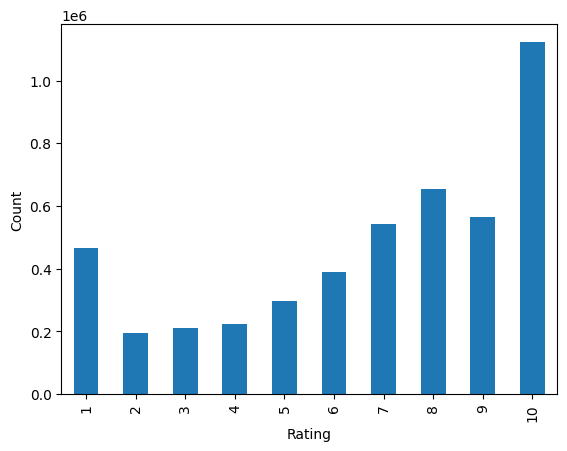

In [16]:
df.ratings.value_counts().sort_index().plot(kind="bar", xlabel="Rating", ylabel="Count")

<Axes: xlabel='dates'>

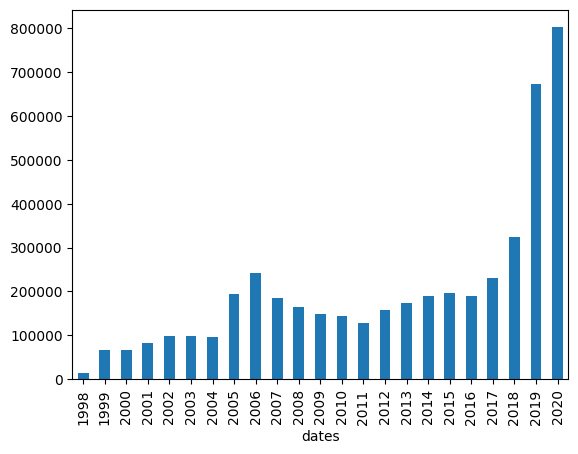

In [23]:
df["dates"].groupby(df["dates"].dt.year).count().plot(kind="bar")

In [19]:
dates = df["dates"].value_counts()
dates

dates
2019-05-20    7291
2020-07-25    5773
2020-07-24    4542
2020-11-21    4045
2019-05-13    3788
              ... 
1998-08-25       7
1998-08-27       6
1998-07-27       3
2002-01-01       2
2018-04-30       1
Name: count, Length: 8028, dtype: int64

### Matrix Factorisation

### Map suggested movie to actual title from IMDB

In [ ]:
# Build slates
# Cosine similarity? for similarity?